In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import glob

from joblib import Parallel, delayed
from scipy.spatial import cKDTree
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
def get_lonlat(f):
    lon = f['lon'].values
    lat = f['lat'].values
    lon[np.abs(lon)>1e4]=np.nan
    lat[np.abs(lat)>1e4]=np.nan
    return lon,lat

def mymap():
    
    fig = plt.figure(figsize=(11,8.5))
    ax=plt.axes(projection=ccrs.PlateCarree(),transform = ccrs.PlateCarree())
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.LAND)

    return fig,ax

In [174]:
from scipy.spatial import cKDTree
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def get_couples_proba(lonA,latA, lonB, latB, plot=False):

    tol_deg = 0.5 # 2*0.1 la spatial resolution des ocean currents
    all_B_points = []
    trajB_index = []
    n_trajB = lonB.shape[0]
    
    for i in range(n_trajB):
        traj = np.column_stack((lonB[i], latB[i]))
        traj = traj[~np.isnan(traj).any(axis=1)]
        
        if len(traj) > 1:
            all_B_points.append(traj)
            trajB_index += [i] * len(traj)
    
    if len(all_B_points) == 0:
        raise ValueError("No valid B trajectories")
    
    all_B_points = np.vstack(all_B_points)
    trajB_index = np.array(trajB_index)
    
    # === Build tree on all B points
    treeB = cKDTree(all_B_points)
    
    couples_set = set()
    plot_pairs = []  # list of (A_trajectory, B_trajectory)
    
    # === Loop on A
    for a in range(lonA.shape[0]):
    
        trajA = np.column_stack((lonA[a], latA[a]))
        trajA = trajA[~np.isnan(trajA).any(axis=1)]
    
        if len(trajA) < 2:
            continue
    
        # === Query all points of trajA against all B
        dist, idx = treeB.query(trajA, distance_upper_bound=tol_deg, k = lonB.shape[0]) # the k = , is where the problem, bc it means how many neighbours is the tree going to look for withing your tol_deg and maybe it misses trajs 
    
        # Remove invalid results (no match)
        valid = idx[dist != np.inf]
        if valid.size == 0:
            continue
        
        close_B_trajs = set(trajB_index[valid])  # matched B trajectory indices
        
        for b in close_B_trajs:
            couples_set.add((a, b))  # record the couple index
            plot_pairs.append((trajA, np.column_stack((lonB[b], latB[b]))))  # store points to plot
    
    if plot:
        # === Plot after the loop
        fig, ax = mymap()
        for pA, pB in plot_pairs:
            ax.plot(pA[:, 0], pA[:, 1], c='skyblue', alpha=0.1)
            ax.plot(pB[:, 0], pB[:, 1], c='mediumseagreen', alpha=0.1)
        plt.show()
    
    # === Report final result
    n_total = lonA.shape[0] * lonB.shape[0]
    proba = 100*len(couples_set)/n_total
    
    return proba


In [5]:
path_gaby = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDriftExp/'

files_gaby_all = glob.glob(path_gaby+'S.*.folder/*_VarWindDrift.nc')

print(len(files_gaby_all))

files_gaby = []
for i in range(len(files_gaby_all)):
    f = xr.open_dataset(files_gaby_all[i])
    
    if len(f['time'])>360:
        files_gaby.append(files_gaby_all[i])

files_gaby = np.array(files_gaby)

print(len(files_gaby))

56
48


In [188]:
path_gaby_hands = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDrift2hands/'

files_gaby_all_left = glob.glob(path_gaby_hands+'S.*.folderL/*.nc')
files_gaby_all_right = glob.glob(path_gaby_hands+'S.*.folderR/*.nc')

print(len(files_gaby_all_right))

files_gaby_left = []
files_gaby_right = []

for i in range(len(files_gaby_all_right)):
    fR = xr.open_dataset(files_gaby_all_right[i])
    fL = xr.open_dataset(files_gaby_all_left[i])
    
    if len(fR['time'])>360:
        files_gaby_right.append(files_gaby_all_right[i])

    if len(fL['time'])>360:
        files_gaby_left.append(files_gaby_all_left[i])

files_gaby_right = np.array(files_gaby_right)
files_gaby_left = np.array(files_gaby_left)

print(len(files_gaby_right))
print(len(files_gaby_left))


66
52
52


In [195]:
files_gaby_run_right = np.sort(np.concatenate([files_gaby, files_gaby_right]))
files_gaby_run_left = np.sort(np.concatenate([files_gaby, files_gaby_left]))

len(files_gaby_run_left)

100

In [213]:
def run_two_2hands(i,j):

    fA_left = xr.open_dataset(files_gaby_run_left[i])
    fA_right = xr.open_dataset(files_gaby_run_right[i])
    
    fB_left = xr.open_dataset(files_gaby_run_left[j])
    fB_right = xr.open_dataset(files_gaby_run_right[j])
    
    lonA_left, latA_left = get_lonlat(fA_left)
    lonA_right, latA_right = get_lonlat(fA_right)

    lonB_left, latB_left = get_lonlat(fB_left)
    lonB_right, latB_right = get_lonlat(fB_right)

    P_LALB = get_couples_proba(lonA_left, latA_left, lonB_left, latB_left, plot=False)
    P_LARB = get_couples_proba(lonA_left, latA_left, lonB_right, latB_right, plot=False)

    P_RALB = get_couples_proba(lonA_right, latA_right, lonB_left, latB_left, plot=False)
    P_RARB = get_couples_proba(lonA_right, latA_right, lonB_right, latB_right, plot=False)
    
    return np.nanmean([P_LALB,P_LARB,P_RALB,P_RARB])
######-----------


def run_one_2hands(i,j):
    
    fA_left = xr.open_dataset(files_gaby_run_left[i])
    fA_right = xr.open_dataset(files_gaby_run_right[i])
    fB = xr.open_dataset(files_gaby_run_left[j])

    lonA_left, latA_left = get_lonlat(fA_left)
    lonA_right, latA_right = get_lonlat(fA_right)

    lonB, latB = get_lonlat(fB)

    P_left = get_couples_proba(lonA_left, latA_left, lonB, latB, plot=False)
    P_right = get_couples_proba(lonA_right, latA_right, lonB, latB, plot=False)

    return np.nanmean([P_left,P_right])

######-----------

def run_no_2hands(i,j):
    
    fA = xr.open_dataset(files_gaby_run_left[i])
    fB = xr.open_dataset(files_gaby_run_left[j])

    lonA, latA = get_lonlat(fA)

    lonB, latB = get_lonlat(fB)

    P = get_couples_proba(lonA, latA, lonB, latB, plot=False)

    return P

In [215]:

P = np.nan*np.ones((len(files_gaby_run_left),len(files_gaby_run_left)))

for i in range(len(files_gaby_run_left)):
    print(i)
    
    for j in tqdm(range(len(files_gaby_run_left))):
        if i == j or not np.isnan(P[j, i]):
            continue

        if "hands" in files_gaby_run_left[i] and "hands" in files_gaby_run_left[j]:
            P[i,j] = run_two_2hands(i,j)
            
        elif "hands" in files_gaby_run_left[i]:
            P[i,j] = run_one_2hands(i,j)
            
        elif "hands" in files_gaby_run_left[j]:
            P[i,j] = run_one_2hands(j,i)
        else:
            P[i,j] = run_no_2hands(i,j)

0


100%|██████████| 100/100 [11:50<00:00,  7.11s/it]


1


100%|██████████| 100/100 [14:23<00:00,  8.64s/it] 


2


100%|██████████| 100/100 [11:57<00:00,  7.17s/it] 


3


 42%|████▏     | 42/100 [13:45<19:00, 19.66s/it]  

KeyboardInterrupt



In [27]:
import re
samples = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby]

print(samples)

[113, 104, 50, 139, 67, 58, 94, 135, 108, 81, 27, 90, 10, 89, 1, 25, 52, 78, 137, 29, 56, 92, 111, 114, 132, 51, 60, 59, 95, 86, 109, 136, 91, 28, 110, 161, 107, 53, 80, 26, 62, 79, 138, 156, 57, 93, 66, 112]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


lineage = pd.read_csv('/srv/scratch/oceanopen/GlobalBlueBottles/SHC_Physalia_lineage_assignments_Nov2024.csv')

P = np.load('proba_connectivity_ALL_FINAL_1000TRAJ_FIXED.npy')

In [4]:
import glob
import xarray as xr

path_gaby = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDriftExp/VarDriftExpHanded/'

files_gaby_all = glob.glob(path_gaby+'*.nc')

print(len(files_gaby_all))

files_gaby = []
for i in range(len(files_gaby_all)):
    f = xr.open_dataset(files_gaby_all[i])
    
    if len(f['time'])>360:
        files_gaby.append(files_gaby_all[i])

files_gaby = np.array(files_gaby)

print(len(files_gaby))



path_gaby_hands = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDrift2hands/'

files_gaby_all_left = glob.glob(path_gaby_hands+'S.*.folderL/*.nc')
files_gaby_all_right = glob.glob(path_gaby_hands+'S.*.folderR/*.nc')

print(len(files_gaby_all_right))

files_gaby_left = []
files_gaby_right = []

for i in range(len(files_gaby_all_right)):
    fR = xr.open_dataset(files_gaby_all_right[i])
    fL = xr.open_dataset(files_gaby_all_left[i])
    
    if len(fR['time'])>360:
        files_gaby_right.append(files_gaby_all_right[i])

    if len(fL['time'])>360:
        files_gaby_left.append(files_gaby_all_left[i])

files_gaby_right = np.array(files_gaby_right)
files_gaby_left = np.array(files_gaby_left)

print(len(files_gaby_right))
print(len(files_gaby_left))

files_gaby_run_right = np.sort(np.concatenate([files_gaby, files_gaby_right]))
files_gaby_run_left = np.sort(np.concatenate([files_gaby, files_gaby_left]))


91
84
66
52
52


In [5]:
p_lin = np.nan*np.zeros((5,5))
p_lin

import tqdm

In [6]:
import re
samples = [int(re.search(r'/(\d+)s_', path).group(1)) for path in files_gaby_run_right]


In [11]:

list_aa, list_b1b1, list_b2b2, list_c1c1, list_c2c2 = [], [], [], [], []
list_ab1, list_ab2, list_ac1, list_ac2 = [], [], [], []
list_b1b2, list_b1c1, list_b1c2 = [], [], []
list_b2c1, list_b2c2 = [], []
list_c1c2 = []

P2 = np.copy(P)
P2[P2==0] = np.nan

for i in range(len(files_gaby_run_right)):
    for j in range(len(files_gaby_run_right)):

        sp_start = lineage['lineage'].values[samples[i]-1]
        sp_end = lineage['lineage'].values[samples[j]-1]

        if sp_start == "A" and sp_end == "A":
            list_aa.append(P[i,j])
        
        if sp_start == "A" and sp_end == "B1":
            list_ab1.append(P[i,j])
            
        if sp_start == "A" and sp_end == "B2":
            list_ab2.append(P[i,j])
            
        if sp_start == "A" and sp_end == "C1":
            list_ac1.append(P[i,j])

        if sp_start == "A" and sp_end == "C2":
            list_ac2.append(P[i,j])

            
        if sp_start == "B1" and sp_end == "B1":
            list_b1b1.append(P[i,j])

        if sp_start == "B1" and sp_end == "B2":
            list_b1b2.append(P[i,j])
            
        if sp_start == "B1" and sp_end == "C1":
            list_b1c1.append(P[i,j])

        if sp_start == "B1" and sp_end == "C2":
            list_b1c2.append(P[i,j])
            
        if sp_start == "B2" and sp_end == "B2":
            list_b2b2.append(P[i,j])

            
        if sp_start == "B2" and sp_end == "C1":
            list_b2c1.append(P[i,j])

        if sp_start == "B2" and sp_end == "C2":
            list_b2c2.append(P[i,j])

        
        if sp_start == "C1" and sp_end == "C1":
            list_c1c1.append(P[i,j])

            
        if sp_start == "C1" and sp_end == "C2":
            list_c1c2.append(P[i,j])
            
        if sp_start == "C2" and sp_end == "C2":
            list_c2c2.append(P[i,j])


In [ ]:
p_lin[0,0] = np.nanmean(list_aa)
p_lin[0,1] = np.nanmean(list_ab1)
p_lin[0,2] = np.nanmean(list_ab2)
p_lin[0,3] = np.nanmean(list_ac1)
p_lin[0,4] = np.nanmean(list_ac2)

p_lin[1,1] = np.nanmean(list_b1b1)
p_lin[1,2] = np.nanmean(list_b1b2)
p_lin[1,3] = np.nanmean(list_b1c1)
p_lin[1,4] = np.nanmean(list_b1c2)

p_lin[2,2] = np.nanmean(list_b2b2)
p_lin[2,3] = np.nanmean(list_b2c1)
p_lin[2,4] = np.nanmean(list_b2c2)

p_lin[3,3] = np.nanmean(list_c1c1)
p_lin[3,4] = np.nanmean(list_c1c2)

p_lin[4,4] = np.nanmean(list_c2c2)

In [ ]:
print('c2', p_lin[0,4], p_lin[1,4], p_lin[2,4], p_lin[3,4])
print('c1', p_lin[0,3], p_lin[1,3], p_lin[2,3])
print('b2', p_lin[2,3], p_lin[1,2])
print('b1', p_lin[0,1])

In [7]:
import searoute as sr

def get_dist_sea(x_start,y_start,x_end,y_end):
    origin = [x_start, y_start]
    destination  = [x_end, y_end]
    route = sr.searoute(origin, destination)
    return route.properties['length']

In [8]:

x_plot = []
y_plot = []
y_plot2 = []

lin1 = []
lin2 = []
for i in range(len(files_gaby_run_right)):    
    for j in range(len(files_gaby_run_right)):
        if i==j:
            continue
        
        x_start = lineage['longitue'].values[samples[i]-1]
        x_end = lineage['longitue'].values[samples[j]-1]
        
        y_start = lineage['latitude'].values[samples[i]-1]
        y_end = lineage['latitude'].values[samples[j]-1]

        lin1.append(lineage['lineage'].values[samples[i]-1])
        lin2.append(lineage['lineage'].values[samples[j]-1])
        
        x_plot.append(get_dist_sea(x_start,y_start,x_end,y_end))

        y_plot.append(P[i,j])
        y_plot2.append(P[j,i])

lin1 = np.array(lin1)
lin2 = np.array(lin2)

In [9]:
c_lin1 = np.nan*np.zeros(lin1.shape)
c_lin1[lin1=="B1"]=1
c_lin1[lin1=="B2"]=2
c_lin1[lin1=="C1"]=3
c_lin1[lin1=="C2"]=4
c_lin1[lin1=="A"]=0

c_lin2 = np.nan*np.zeros(lin2.shape)
c_lin2[lin2=="B1"]=1
c_lin2[lin2=="B2"]=2
c_lin2[lin2=="C1"]=3
c_lin2[lin2=="C2"]=4
c_lin2[lin2=="A"]=0

c_lin2[np.isnan(c_lin1)] = np.nan
c_lin1[np.isnan(c_lin2)] = np.nan

In [10]:
path_fig = '/srv/scratch/oceanopen/Natacha2025/LaunchRun/ReadResults/connectivity_figs/'

##### trying to do something better

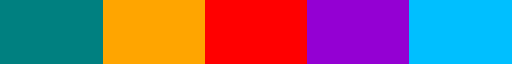

In [12]:
import matplotlib as mpl
cmap_species = mpl.colors.ListedColormap(
    name="species",
    colors=["teal", "orange", "r", "darkviolet", "deepskyblue"]
)
cmap_species

In [19]:
a = x_plot[c_lin1 != c_lin2]
b = y_plot[c_lin1 != c_lin2]



c1 = c_lin1[c_lin1 != c_lin2]
c2 = c_lin2[c_lin1 != c_lin2]

colors1 = np.array(['lightgrey' for i in range(len(c1))]).astype(object)
colors2 = np.array(['lightgrey' for i in range(len(c1))]).astype(object)

colors1[c1 == 0] = 'teal'
colors1[c1 == 1] = 'orange'
colors1[c1 == 2] = 'r'
colors1[c1 == 3] = 'darkviolet'
colors1[c1 == 4] = 'deepskyblue'

colors2[c2 == 0] = 'teal'
colors2[c2 == 1] = 'orange'
colors2[c2 == 2] = 'r'
colors2[c2 == 3] = 'darkviolet'
colors2[c2 == 4] = 'deepskyblue'



# you are here do the plot connectivity vs distance for intra

In [13]:
# Domaines
xlim = (-1, 8577)
ylim = (-1, 101)

# Résolution
nx, ny = 2, 100
x_edges = np.linspace(xlim[0], xlim[1], nx + 1)  # coins, donc +1
y_edges = np.linspace(ylim[0], ylim[1], ny + 1)

# Données Z : ny lignes, nx colonnes
Z = np.tile(np.linspace(.2, 1.3, ny).reshape(-1, 1), (1, nx))


###
# Résolution
nx, ny = 100, 2
x_edges2 = np.linspace(xlim[0], xlim[1], nx + 1)
y_edges2 = np.linspace(ylim[0], ylim[1], ny + 1)

Z2 = np.tile(np.linspace(.2, 1.3, nx), (ny, 1))


/scratch/pbs.6724698.kman.restech.unsw.edu.au/ipykernel_3678849/3240135635.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x_plot[condi], y_plot[condi], c='w', cmap=cmap_species, s=150,alpha=.2,zorder=10)


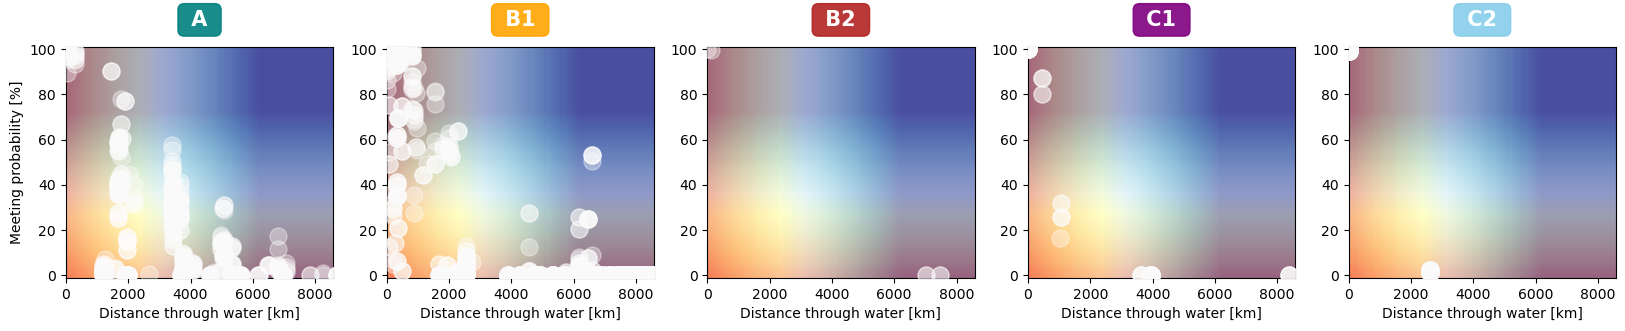

In [15]:
import numpy as np

x_plot = np.array(x_plot)
y_plot = np.array(y_plot)

fig, axs = plt.subplots(ncols=5, nrows=1, figsize=(20,3))

for ax in fig.get_axes():
    ax.set_xlim(-1, 8577)
    ax.set_ylim(-1, 101)

    
    ax.pcolormesh(x_edges2,y_edges2,Z2,zorder=0,alpha=.4*2,cmap='RdYlBu',vmin=0,vmax=1)
    ax.pcolormesh(x_edges,y_edges,Z,zorder=0,alpha=.2*2,cmap='RdYlBu',vmin=0,vmax=1)


for lins,ax in zip([0,1,2,3,4], fig.get_axes()):
    condi = np.logical_and(c_lin1 == lins, c_lin2 == lins)
    ax.scatter(x_plot[condi], y_plot[condi], c='w', cmap=cmap_species, s=150,alpha=.2,zorder=10)
    ax.set_xlabel('Distance through water [km]')


for a,l,color in zip(axs,[' A ',' B1 ',' B2 ',' C1 ',' C2 '], ['teal','orange','firebrick','purple','skyblue']):
    a.set_title(l,bbox={'boxstyle': 'round,pad=0.3', 'facecolor': color,'edgecolor': color,'alpha': 0.9},fontweight='bold',c='w',fontsize=15,pad=15)


axs[0].set_xlabel('Distance through water [km]')

axs[0].set_ylabel('Meeting probability [%]')
fig.savefig(path_fig+'connectivity_vs_distance_subplotsperlineage.png',dpi=500,facecolor='w',bbox_inches='tight')

In [ ]:
import matplotlib as mpl
cmap_species = mpl.colors.ListedColormap(
    name="species",
    colors=["teal", "orange", "r", "darkviolet", "deepskyblue"]
)
cmap_species

# Some maps  from saved file

In [22]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
P = np.load("proba_connectivity_15Apr25.npy")

In [8]:
import re
samples = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby]

lineage = pd.read_csv('/srv/scratch/oceanopen/GlobalBlueBottles/SHC_Physalia_lineage_assignments_Nov2024.csv')
lineage

,sample No.,status,ID,handedness,lineage,subpopulation,vagrant,ocean,location,site,...,permit,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1,high quality,FM-16644,right,A,A:V1,NaN,NE Atlantic,Canary Islands,La Palma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,high quality,YPM-IZ-110716,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,high quality,YPM-IZ-110726,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,high quality,YPM-IZ-110738,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,high quality,YPM-IZ-110842,left,A,A:V1,NaN,NE Atlantic,Azores,"Porto Pim beach, Faial Island, Azores",...,"Secretaria Regional do Mar, Ciência e Tecnolog...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,159,excluded,YPM-IZ-110827,NaN,NaN,NaN,NaN,SE Pacific,Chile,"Morrillos, Coquimbo, Chile",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,160,excluded,YPM-IZ-110879,NaN,NaN,NaN,NaN,Gulf of California,Mexico,Gulf of California,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,161,excluded,YPM-IZ-110973,right,NaN,NaN,NaN,NE Atlantic,Ireland,"Near Dooley's Seafood & Steak House, Watervill...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,162,excluded,YPM-IZ-111015,NaN,NaN,NaN,NaN,NW Atlantic,Bermuda,NaN,...,Bermuda Special Permit no. SP200501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
path_gaby = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDriftExp/'
files_gaby_all = glob.glob(path_gaby+'S.*.folder/*_VarWindDrift.nc')

print(len(files_gaby_all))

files_gaby = []
for i in range(len(files_gaby_all)):
    f=xr.open_dataset(files_gaby_all[i])
    if len(f['time'])>360:
        files_gaby.append(files_gaby_all[i])

files_gaby = np.array(files_gaby)
print(len(files_gaby))

56
48


In [38]:
def get_dist(x1,y1,x2,y2):
    from math import sin, cos, sqrt, atan2, radians
    
    # Approximate radius of earth in km
    R = 6373.0
    
    lat1 = radians(y1)
    lon1 = radians(x1)
    
    lat2 = radians(y2)
    lon2 = radians(x2)
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
    distance = R * c
    return distance

In [36]:

x_plot = []
y_plot = []
y_plot2 = []

lin1 = []
lin2 = []
for i in range(len(files_gaby)):    
    for j in range(len(files_gaby)):
        if i==j:
            continue
        
        x_start = lineage['longitue'].values[samples[i]-1]
        x_end = lineage['longitue'].values[samples[j]-1]
        
        y_start = lineage['latitude'].values[samples[i]-1]
        y_end = lineage['latitude'].values[samples[j]-1]

        lin1.append(lineage['lineage'].values[samples[i]-1])
        lin2.append(lineage['lineage'].values[samples[j]-1])
        
        x_plot.append(get_dist(x_start,y_start,x_end,y_end))

        y_plot.append(P[i,j])
        y_plot2.append(P[j,i])

lin1 = np.array(lin1)
lin2 = np.array(lin2)

In [37]:
c_lin1 = np.zeros(lin1.shape)
c_lin1[lin1=="B1"]=1
c_lin1[lin1=="B2"]=2
c_lin1[lin1=="C1"]=3
c_lin1[lin1=="C2"]=4

c_lin2 = np.zeros(lin2.shape)
c_lin2[lin2=="B1"]=1
c_lin2[lin2=="B2"]=2
c_lin2[lin2=="C1"]=3
c_lin2[lin2=="C2"]=4

# Connectivity intra-species

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

lineage = pd.read_csv('/srv/scratch/oceanopen/GlobalBlueBottles/SHC_Physalia_lineage_assignments_Nov2024.csv')

P = np.load('proba_connectivity_ALL_FINAL.npy')

/scratch/pbs.6694816.kman.restech.unsw.edu.au/ipykernel_2249427/4217023112.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('BuPu')


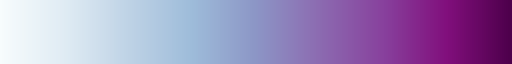

In [23]:
import matplotlib

cmap = matplotlib.cm.get_cmap('BuPu')
cmap

/scratch/pbs.6683375.kman.restech.unsw.edu.au/ipykernel_3630140/2825713968.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('binary')


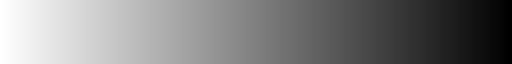

In [45]:
import matplotlib
import cartopy.feature as cfeature
cmap = matplotlib.cm.get_cmap('binary')
cmap

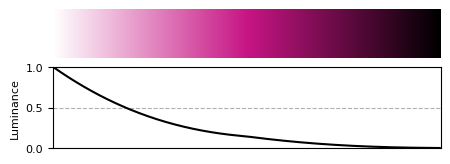

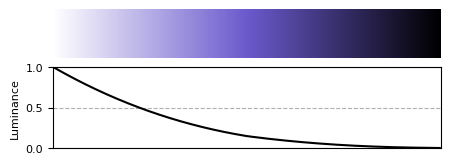

In [27]:
mymap = cmap_seq(['w','mediumvioletred','k'])
mymap = cmap_seq(['w','slateblue','k'])


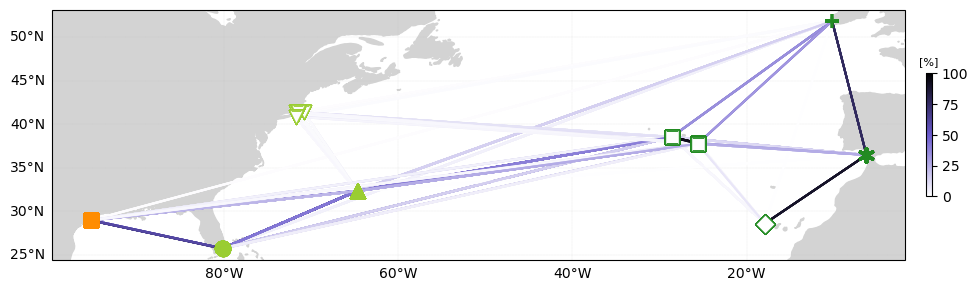

In [49]:
fig = plt.figure(figsize=(11,8.5))
ax=plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,color='lightgrey')

gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--',zorder=0,linewidth=.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = plt.MaxNLocator(6)
gl.ylocator = plt.MaxNLocator(6)

for i in range(len(a)):
    ax.plot(a[i],b[i],c=mymap(c[i]/100),zorder=5)

    if a[i][0] > -100 and a[i][0] < -85:
        ax.scatter(a[i][0],b[i][0],c='darkorange',marker='s',s=100,alpha=.9,zorder=7)

    
    if a[i][0] > -85 and a[i][0] < -75:
        ax.scatter(a[i][0],b[i][0],c='yellowgreen',marker='o',s=100,alpha=.9,zorder=7)

        
    if a[i][0] > -75 and a[i][0] < -65:
        ax.scatter(a[i][0],b[i][0],edgecolor='yellowgreen',facecolor='w',marker='v',s=100,alpha=.9,zorder=7)

    
    if a[i][0] > -65 and a[i][0] < -40:
        ax.scatter(a[i][0],b[i][0],c='yellowgreen',marker='^',s=100,alpha=.9,zorder=7)

        
    if a[i][0] > -65 and a[i][0] < -40:
        ax.scatter(a[i][0],b[i][0],c='yellowgreen',marker='^',s=100,alpha=.9,zorder=7)

    
    if a[i][0] > -40 and a[i][0] < -25:
        ax.scatter(a[i][0],b[i][0],edgecolor='forestgreen',facecolor='w',marker='s',s=100,alpha=.9,zorder=7)
    
    if a[i][0] > -25 and a[i][0] < -15:
        ax.scatter(a[i][0],b[i][0],edgecolor='forestgreen',facecolor='w',marker='D',s=100,alpha=.9,zorder=7)

        
        
    if a[i][0] > -15 and b[i][0] < 40:
        ax.scatter(a[i][0],b[i][0],c='forestgreen',marker='$*$',s=110,alpha=.9,zorder=7)

    
        
    if a[i][0] > -15 and b[i][0] > 40:
        ax.scatter(a[i][0],b[i][0],c='forestgreen',marker='+',s=110,alpha=.9,zorder=7)
        

norm = mcolors.Normalize(vmin=0, vmax=100)
sm = plt.cm.ScalarMappable(cmap=mymap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=.15,pad=0.02)
cbar.ax.set_title('[%]',fontsize=8)
fig.tight_layout()
fig.savefig(path_fig+'connectivity_intraA_FINAL_1000TRAJ_CORRECTED.png',dpi=600,bbox_inches='tight')

In [16]:

def lonlat_to_xyz(lon, lat):
    # Convert degrees to radians
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    # Convert to cartesian coordinates (unit sphere)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack((x, y, z))
earth_radius_km = 6371.0088  # in kilometers

### thing of distances

In [29]:
mylin = "B1"

from tqdm import tqdm
a = []
b = []
c = []
d = []
e = []

P_min  = np.nan*np.ones((len(files_gaby_run_right), len(files_gaby_run_right)))
P_mean  = np.nan*np.ones((len(files_gaby_run_right), len(files_gaby_run_right)))
P_median = np.nan*np.ones((len(files_gaby_run_right), len(files_gaby_run_right)))

for i in tqdm(range(len(files_gaby_run_right))):
    for j in range(len(files_gaby_run_right)):
        
        if i == j or ~np.isnan(P_min[i,j]):
            continue
        
        lin1 = lineage['lineage'].values[samples[i]-1]
        lin2 = lineage['lineage'].values[samples[j]-1]
                
        x_start = lineage['longitue'].values[samples[i]-1]
        x_end = lineage['longitue'].values[samples[j]-1]
        
        y_start = lineage['latitude'].values[samples[i]-1]
        y_end = lineage['latitude'].values[samples[j]-1]
        
        both_b1 = np.logical_and(type(lin1) == str and lin1 == mylin, type(lin2) == str and lin2 == mylin)
        
        if not both_b1:
            continue

        for index in [i,j]:
            
            if files_gaby_run_left[index] == files_gaby_run_right[index]:
                f = xr.open_dataset(files_gaby_run_left[index])

                if index == i:
                    lon_i = f['lon'][:,-1]
                    lat_i = f['lat'][:,-1]
                else:
                    lon_j = f['lon'][:,-1]
                    lat_j = f['lat'][:,-1]
            else:
                fL_ori = xr.open_dataset(files_gaby_run_left[index])
                fR_ori = xr.open_dataset(files_gaby_run_right[index])
                
                fL = fL_ori.isel(trajectory = np.arange(0,1000,2))
                fR = fR_ori.isel(trajectory = np.arange(0,1000,2))                
                
                if index == i:
                    lon_i = np.concatenate([fL['lon'][:,-1],fR['lon'][:,-1]])
                    lat_i = np.concatenate([fL['lat'][:,-1],fR['lat'][:,-1]])
                else:
                    lon_j = np.concatenate([fL['lon'][:,-1],fR['lon'][:,-1]])
                    lat_j = np.concatenate([fL['lat'][:,-1],fR['lat'][:,-1]])


        xyz_i = lonlat_to_xyz(lon_i, lat_i)
        xyz_j = lonlat_to_xyz(lon_j, lat_j)
                
        dist_matrix_rad = np.arccos(np.clip(np.dot(xyz_i, xyz_j.T), -1.0, 1.0))
        dist_matrix_km = dist_matrix_rad * earth_radius_km
        
        P_min[i,j] = np.nanmin(dist_matrix_km)
        P_mean[i,j] = np.nanmean(dist_matrix_km)
        P_median[i,j] = np.nanmedian(dist_matrix_km)

        c.append(P_min[i,j])
        d.append(P_mean[i,j])
        e.append(P_median[i,j])

        a.append([x_start,x_end])
        b.append([y_start,y_end])

100%|██████████| 136/136 [17:39<00:00,  7.79s/it] 


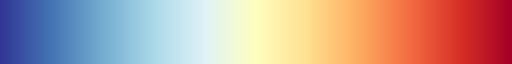

In [18]:
mymap = plt.get_cmap('RdYlBu_r')
mymap

/scratch/pbs.6496726.kman.restech.unsw.edu.au/ipykernel_657945/2056869382.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


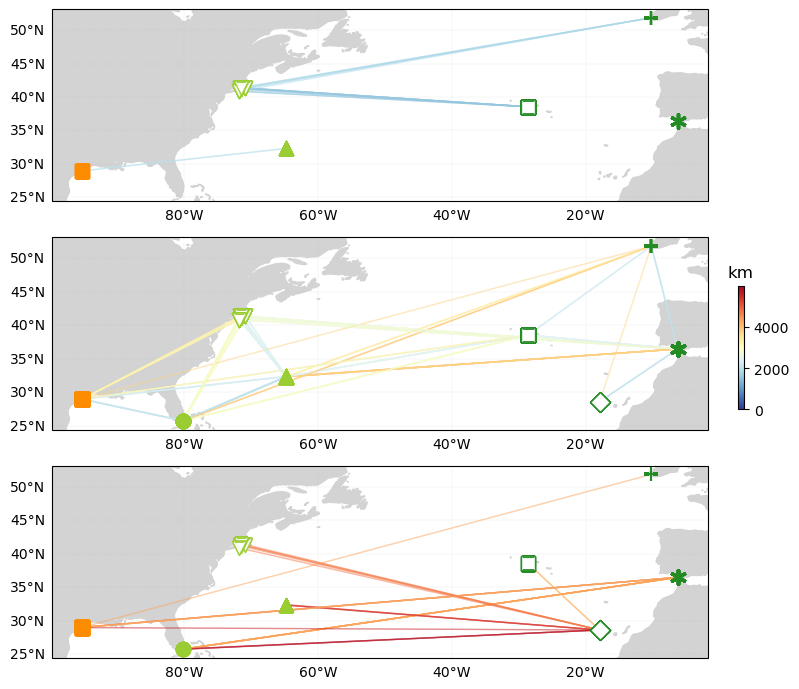

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- Normalisation et colormap ---
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(d))
sm = plt.cm.ScalarMappable(cmap=mymap, norm=norm)
sm.set_array([])

fig, axs = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})

thresholds = [(0, 1/3), (1/3, 2/3), (2/3, 1)]

for idx, ax in enumerate(axs):
    ax.add_feature(cfeature.LAND, color='lightgrey')
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    # Plot selon le seuil correspondant
    for i in range(len(a)):
        e_norm = d[i] / np.nanmax(d)
        if thresholds[idx][0] <= e_norm < thresholds[idx][1]:
            ax.plot(np.mod(a[i], 360), b[i], c=mymap(e_norm), 
                    zorder=5, transform=ccrs.PlateCarree(), alpha=0.3, linewidth=1)
        

            for aa, bb in zip(a[i],b[i]):

                if aa > -100 and aa < -85:
                    ax.scatter(aa,bb,c='darkorange',marker='s',s=100,alpha=.9,zorder=7)
            
                
                if aa > -85 and aa < -75:
                    ax.scatter(aa,bb,c='yellowgreen',marker='o',s=100,alpha=.9,zorder=7)
            
                    
                if aa > -75 and aa < -65:
                    ax.scatter(aa,bb,edgecolor='yellowgreen',facecolor='w',marker='v',s=100,alpha=.9,zorder=7)
            
                
                if aa > -65 and aa < -40:
                    ax.scatter(aa,bb,c='yellowgreen',marker='^',s=100,alpha=.9,zorder=7)
            
                    
                if aa > -65 and aa < -40:
                    ax.scatter(aa,bb,c='yellowgreen',marker='^',s=100,alpha=.9,zorder=7)
            
                
                if aa > -40 and aa < -25:
                    ax.scatter(aa,bb,edgecolor='forestgreen',facecolor='w',marker='s',s=100,alpha=.9,zorder=7)
                
                if aa > -25 and aa < -15:
                    ax.scatter(aa,bb,edgecolor='forestgreen',facecolor='w',marker='D',s=100,alpha=.9,zorder=7)
            
                    
                    
                if aa > -15 and bb < 40:
                    ax.scatter(aa,bb,c='forestgreen',marker='$*$',s=110,alpha=.9,zorder=7)
            
                
                    
                if aa > -15 and bb > 40:
                    ax.scatter(aa,bb,c='forestgreen',marker='+',s=110,alpha=.9,zorder=7)

# --- Colorbar commune ---
cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.23, pad=-.44)
cbar.ax.set_title('km')
fig.tight_layout()
fig.savefig(path_fig + 'distances_intra'+mylin+'_subplots_triples.png', dpi=600, bbox_inches='tight')


/scratch/pbs.6519111.kman.restech.unsw.edu.au/ipykernel_1272114/2261145709.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


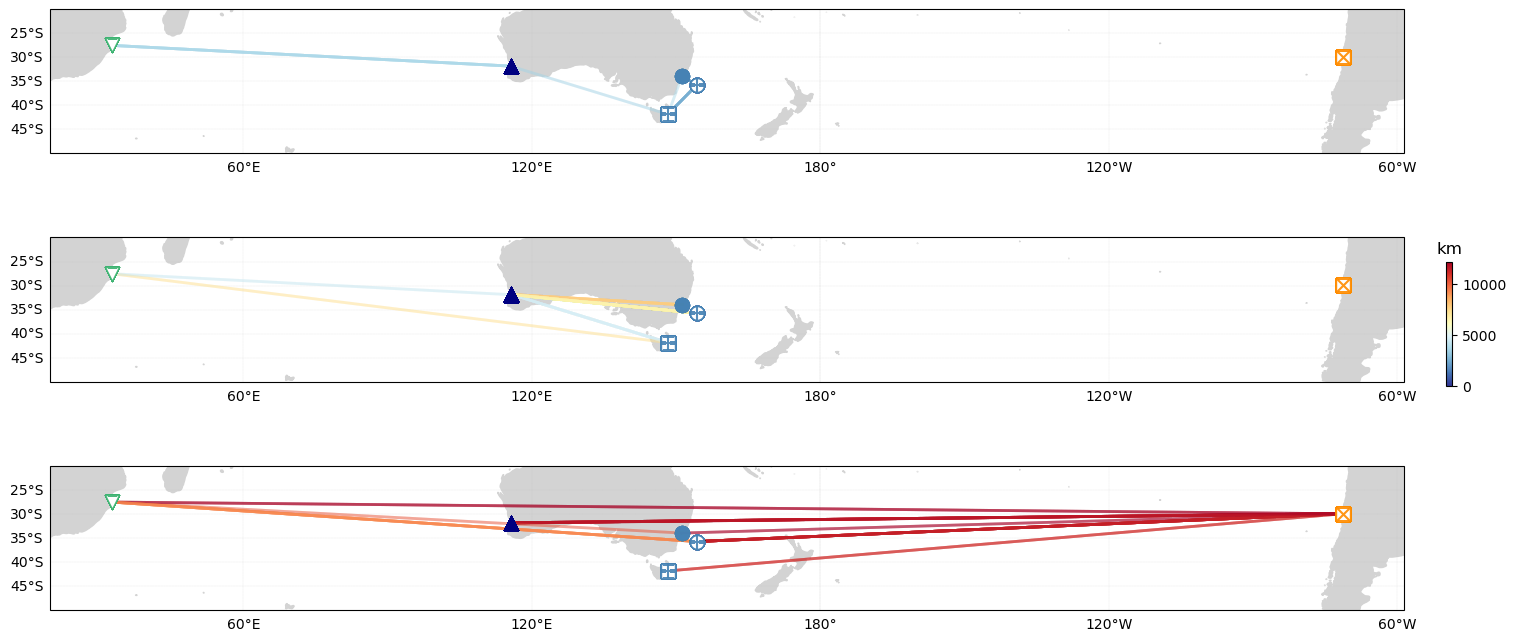

In [88]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- Normalisation et colormap ---
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(d))
sm = plt.cm.ScalarMappable(cmap=mymap, norm=norm)
sm.set_array([])

fig, axs = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

thresholds = [(0, 1/3), (1/3, 2/3), (2/3, 1)]

for idx, ax in enumerate(axs):
    ax.add_feature(cfeature.LAND, color='lightgrey')
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    # Plot selon le seuil correspondant
    for i in range(len(a)):
        e_norm = d[i] / np.nanmax(d)
        if thresholds[idx][0] <= e_norm < thresholds[idx][1]:
            ax.plot(np.mod(a[i], 360), b[i], c=mymap(e_norm), 
                    zorder=5, transform=ccrs.PlateCarree(), alpha=0.3, linewidth=2)

    
        for aa, bb in zip(a[i], b[i]):
    
            if aa < 60 and aa > 0:
                ax.scatter(aa,bb,facecolor='w',edgecolor='mediumseagreen',marker='v',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                
            if aa > 60 and aa < 120:
                ax.scatter(aa,bb,color='navy',marker='^',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                
            if aa > 60 and aa < 120:
                ax.scatter(aa,bb,color='navy',marker='^',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
            
            if bb < -40:
                ax.scatter(aa,bb,facecolor='w',edgecolor='steelblue',marker='s',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='steelblue',marker='+',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if bb > -40 and bb <-35:
                ax.scatter(aa,bb,facecolor='w',edgecolor='steelblue',marker='o',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='steelblue',marker='+',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa < -60 and aa > -120:
                ax.scatter(aa,bb,facecolor='w',edgecolor='darkorange',marker='s',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='darkorange',marker='x',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa > 120 and bb > -35:
                ax.scatter(aa,bb,color='steelblue',marker='o',s=100,alpha=.3,zorder=7, transform=ccrs.PlateCarree())

    ax.set_ylim(-50,-20)

        
# --- Colorbar commune ---
cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.23, pad=-.44)
cbar.ax.set_title('km')
fig.tight_layout()
fig.savefig(path_fig + 'distances_intraC1_subplots_triplesFINAL.png', dpi=600, bbox_inches='tight')


/scratch/pbs.6694816.kman.restech.unsw.edu.au/ipykernel_2249427/1362346068.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


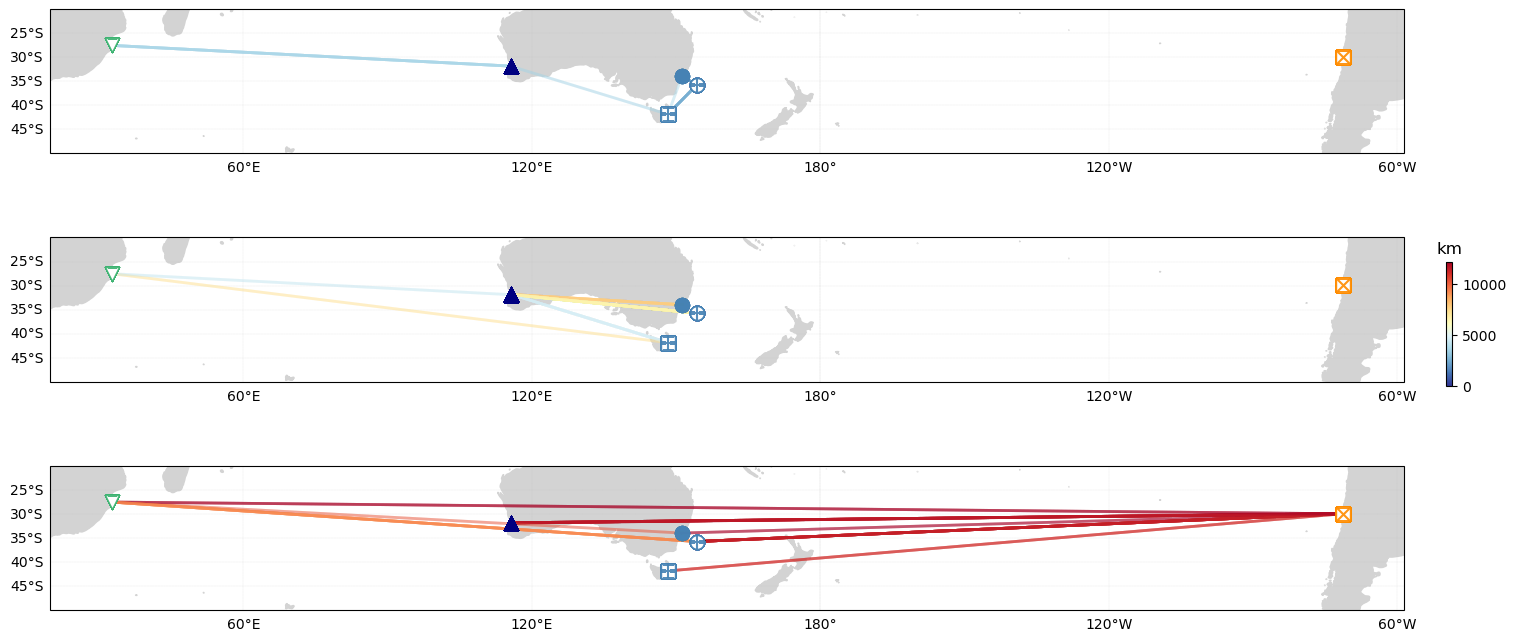

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- Normalisation et colormap ---
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(d))
sm = plt.cm.ScalarMappable(cmap=mymap, norm=norm)
sm.set_array([])

fig, axs = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

thresholds = [(0, 1/3), (1/3, 2/3), (2/3, 1)]

for idx, ax in enumerate(axs):
    ax.add_feature(cfeature.LAND, color='lightgrey')
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    # Plot selon le seuil correspondant
    for i in range(len(a)):
        e_norm = d[i] / np.nanmax(d)
        if thresholds[idx][0] <= e_norm < thresholds[idx][1]:
            ax.plot(np.mod(a[i], 360), b[i], c=mymap(e_norm), 
                    zorder=5, transform=ccrs.PlateCarree(), alpha=0.3, linewidth=2)

    
        for aa, bb in zip(a[i], b[i]):
    
            if aa < 60 and aa > 0:
                ax.scatter(aa,bb,facecolor='w',edgecolor='mediumseagreen',marker='v',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                
            if aa > 60 and aa < 120:
                ax.scatter(aa,bb,color='navy',marker='^',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                
            if aa > 60 and aa < 120:
                ax.scatter(aa,bb,color='navy',marker='^',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
            
            if bb < -40:
                ax.scatter(aa,bb,facecolor='w',edgecolor='steelblue',marker='s',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='steelblue',marker='+',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if bb > -40 and bb <-35:
                ax.scatter(aa,bb,facecolor='w',edgecolor='steelblue',marker='o',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='steelblue',marker='+',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa < -60 and aa > -120:
                ax.scatter(aa,bb,facecolor='w',edgecolor='darkorange',marker='s',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                ax.scatter(aa,bb,color='darkorange',marker='x',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa > 120 and bb > -35:
                ax.scatter(aa,bb,color='steelblue',marker='o',s=100,alpha=.3,zorder=7, transform=ccrs.PlateCarree())

    ax.set_ylim(-50,-20)

        
# --- Colorbar commune ---
cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.23, pad=-.44)
cbar.ax.set_title('km')
fig.tight_layout()
fig.savefig(path_fig + 'distances_intraC1_subplots_triplesFINAL1000TRAJ_CORRECTED.png', dpi=600, bbox_inches='tight')


/scratch/pbs.6694816.kman.restech.unsw.edu.au/ipykernel_2249427/1940752918.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


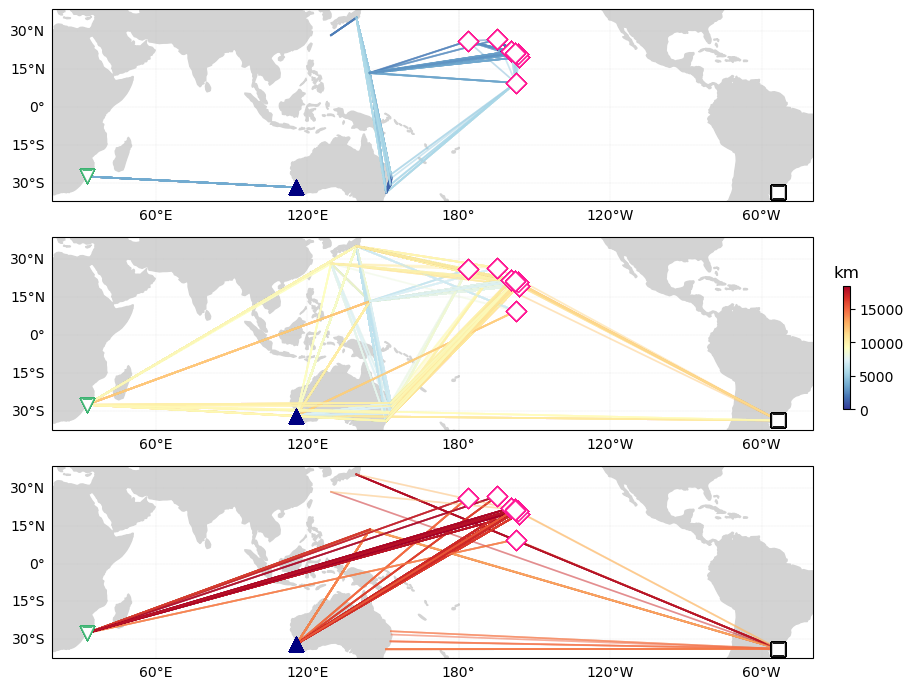

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- Normalisation et colormap ---
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(d))
sm = plt.cm.ScalarMappable(cmap=mymap, norm=norm)
sm.set_array([])

fig, axs = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

thresholds = [(0, 1/3), (1/3, 2/3), (2/3, 1)]

for idx, ax in enumerate(axs):
    ax.add_feature(cfeature.LAND, color='lightgrey')
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    # Plot selon le seuil correspondant
    for i in range(len(a)):
        e_norm = d[i] / np.nanmax(d)
        if thresholds[idx][0] <= e_norm < thresholds[idx][1]:
            ax.plot(np.mod(a[i], 360), b[i], c=mymap(e_norm), 
                    zorder=5, transform=ccrs.PlateCarree(), alpha=0.3, linewidth=1.2)
        
        for aa, bb in zip(a[i], b[i]):
    
            if aa < 60 and aa > 0:
                ax.scatter(aa,bb,facecolor='w',edgecolor='mediumseagreen',marker='v',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())
                
            if aa > 60 and aa < 120:
                ax.scatter(aa,bb,color='navy',marker='^',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa <0 and aa > -80:
                ax.scatter(aa,bb,edgecolor='k',marker='s', facecolor='w',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            if aa <0 and aa < -80:
                ax.scatter(aa,bb,edgecolor='deeppink',marker='D', facecolor='w',s=100,alpha=.9,zorder=7, transform=ccrs.PlateCarree())

            
# --- Colorbar commune ---
cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.23, pad=-.44)
cbar.ax.set_title('km')
fig.tight_layout()
fig.savefig(path_fig + 'distances_intraB1_subplots_triplesFINAL_1000TRAJCORRECTED.png', dpi=600, bbox_inches='tight')
